# Summary

Lets fit the models to the actual data.

---
# Setup

In [1]:
# @title Imports
import pandas as pd
import matplotlib.pyplot as plt

from popy.plotting.plotting_tools import *
from popy.behavior_data_tools import *
from popy.config import PROJECT_PATH_LOCAL

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-1_g4a6pw because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


---
# Simulated agent behavior

In [2]:
# check data for example monkey
monkey = 'ka'
behav = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_first15', f'simulation_behaviors_{monkey}.pkl'))
behav

,monkey,model,session,trial_id,block_id,best_arm,action,reward
0,ka,recording,010720,1,0,1,2.0,0.0
1,ka,recording,010720,2,0,1,0.0,1.0
2,ka,recording,010720,3,0,1,0.0,0.0
3,ka,recording,010720,4,0,1,2.0,1.0
4,ka,recording,010720,5,0,1,2.0,0.0
...,...,...,...,...,...,...,...,...
1523855,ka,Foraging - no reset,0,99995,2497,1,1.0,1.0
1523856,ka,Foraging - no reset,0,99996,2497,1,1.0,0.0
1523857,ka,Foraging - no reset,0,99997,2497,1,1.0,1.0
1523858,ka,Foraging - no reset,0,99998,2497,1,1.0,0.0


In [3]:
behav.model.unique()

array(['recording', 'Repeating agent', 'Standard RL',
       'Standard RL - stickiness',
       'Inferential RL - stickiness + spatial bias', 'Inferential RL',
       'WSLS', 'Foraging - adaptive threshold',
       'Foraging - abandoned bias + spatial bias', 'Foraging',
       'Inferential RL - stickiness', 'Standard RL - forgetting',
       'Standard RL - stickiness + forgetting',
       'Inferential RL - stickiness + multiple alphas',
       'Foraging - abandoned bias', 'Foraging - no reset'], dtype=object)

In [4]:
agents_to_show = {
    'recording': 'recording',
    'WSLS': 'WSLS',
    'Standard RL - stickiness': 'Standard RL',
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
}

Processing monkey: ka


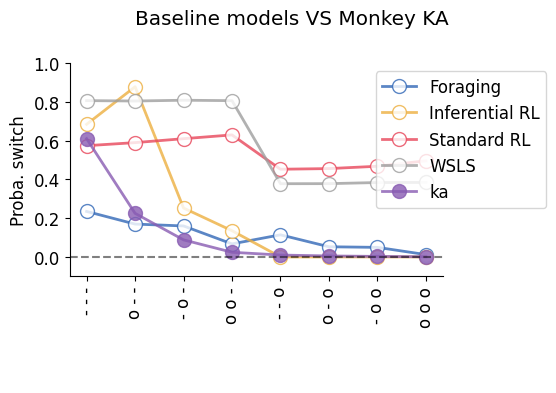

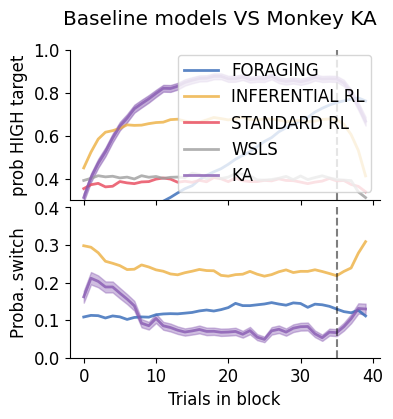

Processing monkey: po


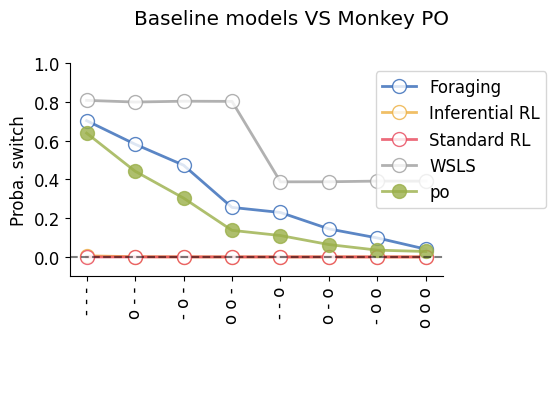

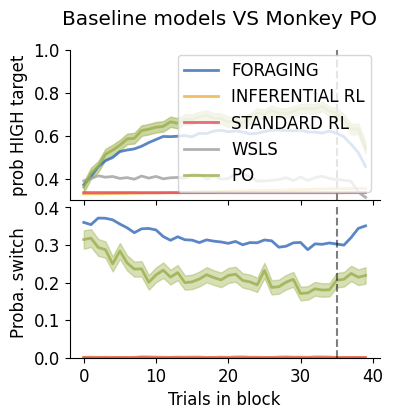

In [5]:
for monkey in ['ka', 'po']:#, 'yu_sham', 'yu_DCZ']:
    print(f'Processing monkey: {monkey}')
    behav = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_first15', f'simulation_behaviors_{monkey}.pkl'))
    # remove n_target_touches column if exists
    if 'n_target_touches' in behav.columns:
        behav = behav.drop(columns=['n_target_touches'])
    # keep only models in agents_to_show.keys() and renaming them
    behav = behav[behav['model'].isin(agents_to_show.keys())].copy()
    behav['model'] = behav['model'].map(agents_to_show)
    # rename 'recording' to 'monkey'
    behav['model'] = behav['model'].replace({'recording': monkey})

    # Apply the function to create the monkey column
    behav['monkey'] = behav['model']

    behav = convert_column_format(behav, original='simulation')

    behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1))
    behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
    behav = behav.dropna()

    fig1, _ = plot_hist_thingy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=False)
    # remove legend
    plt.legend([], [], frameon=False)
    fig2, _ = plot_strategy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=False)
    # remove legend
    plt.legend([], [], frameon=False)

    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_history_thing.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)